In [2]:
import pandas as pd

sheets = pd.read_excel("indicatorsMY_v01.xlsx", sheet_name=None)

# Vérifie les noms des feuilles
print(sheets.keys())

# Exemple : afficher les premières lignes de la feuille 'Alternatives'
df = sheets['Alternatives']
df.shape

dict_keys(['Alternatives', 'Market_Indicators', 'Price_Level_BTC', 'Open_Interests_Futures', 'Money_Supply', 'Central_Banks_Balance_Sheets', 'Central_Banks_Policy_Rates', 'TED_Spreads', '3M_Gov__Bonds', 'Yield_Curve', 'Foreign_Exchange', 'Miscellaneous', 'Gross_Domestic_Products', 'Industrial_Production', 'Retail_Sales', 'Inflation', 'Economic_Surprises', 'Economic Policy Uncertainty', 'Semiconductor_Market_Dynamics', 'Fear&Grid', 'OnChain'])


(136, 5869)

In [3]:
import pandas as pd

df_list = []

for name, sheet in sheets.items():
    #  Nettoyage de base
    sheet = sheet.dropna(how='all', axis=0)
    sheet = sheet.dropna(how='all', axis=1)
    
    #  Vérifier qu’il y a au moins 3 colonnes (sinon ignorer)
    if sheet.shape[1] < 3:
        continue
    
    #  Renommer les deux premières colonnes
    sheet.columns = ['Ticker', 'Variable'] + list(sheet.columns[2:])
    
    #  Transformer les dates en lignes (unpivot / melt)
    melted = sheet.melt(
        id_vars=['Ticker', 'Variable'],
        var_name='Date',
        value_name='Value'
    )
    
    #  Nettoyer les dates et valeurs
    melted['Date'] = pd.to_datetime(melted['Date'], errors='coerce')
    melted = melted.dropna(subset=['Date', 'Value'])
    
    #  Nettoyer les chaînes de texte (espaces, majuscules, etc.)
    melted['Ticker'] = melted['Ticker'].astype(str).str.strip()
    melted['Variable'] = melted['Variable'].astype(str).str.strip()
    
    #  Ajouter le nom de la feuille (pour traçabilité)
    melted['Category'] = name
    
    df_list.append(melted)

#  Fusion finale
merged_df = pd.concat(df_list, ignore_index=True)

#  Sauvegarde du dataset propre
merged_df.to_csv("clean_bitcoin_macro_dataset.csv", index=False)

print("Fusion terminée avec succès !")
print("Nombre total de lignes :", merged_df.shape[0])
print("Nombre total de colonnes :", merged_df.shape[1])
print("Exemple de données :")
print(merged_df.head(10))


C:\Users\marce\AppData\Local\Temp\ipykernel_13592\2392487910.py:25: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  melted['Date'] = pd.to_datetime(melted['Date'], errors='coerce')


Fusion terminée avec succès !
Nombre total de lignes : 935387
Nombre total de colonnes : 5
Exemple de données :
       Ticker Variable                 Date     Value      Category
0  DXY Curncy  px_open  2009-10-12 00:00:00  76.34801  Alternatives
1  DXY Curncy  px_last  2009-10-12 00:00:00  76.12601  Alternatives
2  DXY Curncy  px_high  2009-10-12 00:00:00  76.66801  Alternatives
3  DXY Curncy   px_low  2009-10-12 00:00:00    76.021  Alternatives
4  XAU Curncy  px_open  2009-10-12 00:00:00    1049.2  Alternatives
5  XAU Curncy  px_last  2009-10-12 00:00:00   1057.03  Alternatives
6  XAU Curncy  px_high  2009-10-12 00:00:00   1059.28  Alternatives
7  XAU Curncy   px_low  2009-10-12 00:00:00    1047.2  Alternatives
8   SPX Index  px_open  2009-10-12 00:00:00   1071.63  Alternatives
9   SPX Index  px_last  2009-10-12 00:00:00   1076.19  Alternatives


In [4]:
merged_df[['Category', 'Ticker', 'Variable']].drop_duplicates().head(50)

,Category,Ticker,Variable
0,Alternatives,DXY Curncy,px_open
1,Alternatives,DXY Curncy,px_last
2,Alternatives,DXY Curncy,px_high
3,Alternatives,DXY Curncy,px_low
4,Alternatives,XAU Curncy,px_open
5,Alternatives,XAU Curncy,px_last
6,Alternatives,XAU Curncy,px_high
7,Alternatives,XAU Curncy,px_low
8,Alternatives,SPX Index,px_open
9,Alternatives,SPX Index,px_last


In [5]:
merged_df["Value"].dtype, merged_df["Value"].head()

(dtype('O'),
 0    76.34801
 1    76.12601
 2    76.66801
 3      76.021
 4      1049.2
 Name: Value, dtype: object)

In [6]:
# Nettoyage global de la colonne Value
merged_df["Value"] = (
    merged_df["Value"]
    .astype(str)         # convertir en string
    .str.replace(",", ".")  # remplacer virgules
    .str.replace(" ", "")   # enlever espaces
    .str.replace("-", "")    # remplacer les tirets
)

# Conversion en float
merged_df["Value"] = pd.to_numeric(merged_df["Value"], errors="coerce")

In [7]:
# Convert all dates to datetime
merged_df["Date"] = pd.to_datetime(merged_df["Date"], errors="coerce")

# Force all dates to be timezone-naive
merged_df["Date"] = merged_df["Date"].dt.tz_localize(None)

In [8]:
pivot_df = merged_df.pivot_table(
    index="Date",
    columns="Ticker",
    values="Value",
    aggfunc='mean'   # corrige les doublons mélangés
)

corr = pivot_df.corr()
corr


Ticker,BASPTDSP Index,BDIY Index,BOJDPBAL Index,CCMP Index,CESICNY Index,CESIEUR Index,CESIJPY Index,CESIUSD Index,CFC5QNCN Index,CFC5QOIN Index,...,WGDPUS Index,XADUSD Curncy,XAU Curncy,XBNUSD Curncy,XBTUSD Curncy,XDGUSD Curncy,XETUSD Curncy,XLCUSD Curncy,XRPUSD Curncy,XSOUSD Curncy
Ticker,,,,,,,,,,,,,,,,,,,,,
BASPTDSP Index,1.000000,0.112017,0.304801,0.074222,-0.053814,0.031268,-0.157373,0.263389,0.250862,0.509872,...,0.052645,NaN,0.425114,0.155527,-0.093584,NaN,0.212377,0.112652,-0.012216,NaN
BDIY Index,0.112017,1.000000,0.050543,0.256508,-0.069542,0.080558,0.180371,-0.050104,0.184412,0.221020,...,0.858909,0.064751,0.151326,0.238371,0.285652,-0.030182,0.522776,0.468170,0.155017,-0.059235
BOJDPBAL Index,0.304801,0.050543,1.000000,0.479337,-0.108383,-0.147542,-0.140576,-0.152316,NaN,NaN,...,0.359531,0.466866,0.759721,0.089052,0.567184,0.404768,0.309741,0.024581,0.681880,0.330593
CCMP Index,0.074222,0.256508,0.479337,1.000000,0.052078,0.138508,0.013169,0.050675,-0.281469,-0.160226,...,0.658447,0.411718,0.692582,-0.088430,0.731843,0.384020,0.488304,0.100221,0.462725,0.364603
CESICNY Index,-0.053814,-0.069542,-0.108383,0.052078,1.000000,0.175646,0.173637,0.194962,0.170704,0.462412,...,0.312382,-0.344179,-0.021694,-0.085178,-0.062841,-0.312590,-0.162110,-0.050611,-0.216132,-0.078741
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
XDGUSD Curncy,NaN,-0.030182,0.404768,0.384020,-0.312590,-0.445710,0.006876,-0.351906,NaN,NaN,...,0.880650,0.895555,0.645556,0.740652,0.826001,1.000000,0.684444,0.701926,0.756862,0.826850
XETUSD Curncy,0.212377,0.522776,0.309741,0.488304,-0.162110,-0.229190,0.096438,-0.275997,0.810246,0.826600,...,0.694117,0.673763,0.674886,0.232232,0.828394,0.684444,1.000000,0.485001,0.615876,0.769069
XLCUSD Curncy,0.112652,0.468170,0.024581,0.100221,-0.050611,0.154544,0.395098,-0.129427,0.731006,0.767957,...,0.194709,0.744419,0.066803,0.695102,0.289245,0.701926,0.485001,1.000000,0.349267,0.704839


In [9]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# ============================================================
# CONFIGURATION
# ============================================================

START_DATE = "2018-03-01"
HORIZONS = [14, 30, 60, 90, 120, 150]  # Différents horizons temporels
RETURN_TYPE = "simple"  # "simple" ou "log"

# ============================================================
# FONCTION POUR CALCULER LES RENDEMENTS
# ============================================================

def calculate_returns(prices, horizon, return_type="simple"):
    """
    Calcule les rendements futurs SANS data leakage
    
    return_type:
    - "simple": (P_t+h - P_t) / P_t
    - "log": ln(P_t+h / P_t)
    """
    if return_type == "simple":
        # Rendement simple cumulé sur horizon jours
        future_price = prices.shift(-horizon)
        returns = (future_price - prices) / prices
    else:  # log
        log_prices = np.log(prices)
        log_ret = log_prices.diff()
        returns = log_ret.shift(-horizon).rolling(horizon).sum()
    
    return returns

# ============================================================
# FONCTION POUR CLASSIFIER PAR SCÉNARIOS
# ============================================================

def classify_scenario(returns):
    """
    Classifie les rendements en 5 scénarios basés sur l'écart-type
    
    Scénarios:
    - 0: Fortement baissier (< -1 std)
    - 1: Baissier (-1 std à -0.5 std)
    - 2: Neutre (-0.5 std à +0.5 std)
    - 3: Haussier (+0.5 std à +1 std)
    - 4: Fortement haussier (> +1 std)
    """
    mean_ret = returns.mean()
    std_ret = returns.std()
    
    scenarios = pd.Series(index=returns.index, dtype=int)
    
    scenarios[returns < mean_ret - std_ret] = 0  # Fortement baissier
    scenarios[(returns >= mean_ret - std_ret) & (returns < mean_ret - 0.5*std_ret)] = 1  # Baissier
    scenarios[(returns >= mean_ret - 0.5*std_ret) & (returns <= mean_ret + 0.5*std_ret)] = 2  # Neutre
    scenarios[(returns > mean_ret + 0.5*std_ret) & (returns <= mean_ret + std_ret)] = 3  # Haussier
    scenarios[returns > mean_ret + std_ret] = 4  # Fortement haussier
    
    return scenarios


# =============================
# test
# =============================

def drop_by_mode(X, mode="no_btc_level"):
    if mode in ["no_btc_level", "macro_only"]:
        X = X.drop(columns=[c for c in X.columns if "XBTUSD" in c], errors="ignore")

    if mode == "macro_only":
        crypto_keywords = ["USD Curncy"]  # à affiner avec une vraie liste
        # mieux: une liste explicite des tickers crypto / miners / OI
        drop_list = [c for c in X.columns if c in ["RIOT US Equity","MARA US Equity","IREN US Equity","CORZ US Equity"]
                     or "Open_Interests" in c or "OnChain" in c]
        X = X.drop(columns=drop_list, errors="ignore")
    return X

def fit_scenario_bins(train_returns, n_bins=5):
    qs = np.quantile(train_returns.dropna(), np.linspace(0,1,n_bins+1))
    qs[0], qs[-1] = -np.inf, np.inf
    return qs

def apply_scenario_bins(returns, bins):
    return pd.cut(returns, bins=bins, labels=False, include_lowest=True)


# ============================================================
# FONCTION D'ÉVALUATION POUR UN HORIZON DONNÉ
# ============================================================

def evaluate_horizon_comprehensive(df_original, horizon, return_type="simple"):
    """
    Évaluation complète pour un horizon donné
    Retourne régression ET classification par scénarios
    """
    
    df = df_original.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    df = df[df.index >= START_DATE]
    
    # Nettoyer les features
    #df_features = df.ffill().bfill()
    #df_features = df_features.dropna(axis=1)
    
    df_features = df.ffill()           # PAS de bfill
    # on drop les colonnes trop vides (ex: >20% NA)
    min_non_na = int(0.8 * len(df_features))
    df_features = df_features.dropna(axis=1, thresh=min_non_na)

    
    # Calculer les rendements
    btc_price = df["XBTUSD Curncy"]
    returns = calculate_returns(btc_price, horizon, return_type)
    
    # Target pour régression
    df_features["target_reg"] = returns
    
    # Target pour classification (scénarios)
    scenarios = classify_scenario(returns.dropna())
    df_features["target_class"] = scenarios
    
    # Supprimer les NaN
    df_clean = df_features.dropna(subset=["target_reg", "target_class"])
    
    if len(df_clean) < 100:
        return None
    
    # Séparer X/y
    y_reg = df_clean["target_reg"]
    y_class = df_clean["target_class"]
    X = df_clean.drop(columns=["target_reg", "target_class"])
    
    # Retirer colonnes BTC
    X = X.drop(columns=[c for c in X.columns if "logret" in c.lower()], errors='ignore')
    # btc_cols = [c for c in X.columns if "XBTUSD" in c or "logret" in c.lower()]
    # X = X.drop(columns=btc_cols, errors='ignore')

    # Retirer TOUTES les colonnes crypto en prix + dérivés
    # crypto_cols = [c for c in X.columns if any(x in c for x in 
    #     ["XBTUSD", "XETUSD", "XRPUSD", "XBNUSD", "XLCUSD", "logret", "logreturn"])]
    # X = X.drop(columns=crypto_cols, errors='ignore')
    # print(f"   Colonnes crypto retirées: {len(crypto_cols)}")

    # Split temporel
    train_size = int(0.8 * len(X))
    X_train = X.iloc[:train_size]
    X_test = X.iloc[train_size:]
    y_reg_train = y_reg.iloc[:train_size]
    y_reg_test = y_reg.iloc[train_size:]
    y_class_train = y_class.iloc[:train_size]
    y_class_test = y_class.iloc[train_size:]
    
    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # ============================================================
    # MODÈLE DE RÉGRESSION
    # ============================================================
    
    rf_reg = RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    )
    
    rf_reg.fit(X_train_scaled, y_reg_train)
    y_reg_pred = rf_reg.predict(X_test_scaled)
    
    # Métriques régression
    rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
    r2 = r2_score(y_reg_test, y_reg_pred)
    dir_acc_reg = (np.sign(y_reg_test) == np.sign(y_reg_pred)).mean()
    
    # Feature importance régression
    imp_reg = pd.DataFrame({
        "feature": X_train.columns,
        "importance": rf_reg.feature_importances_
    }).sort_values("importance", ascending=False)
    
    # ============================================================
    # MODÈLE DE CLASSIFICATION (SCÉNARIOS)
    # ============================================================
    
    rf_class = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    
    rf_class.fit(X_train_scaled, y_class_train)
    y_class_pred = rf_class.predict(X_test_scaled)
    
    # Métriques classification
    acc_class = accuracy_score(y_class_test, y_class_pred)
    cm = confusion_matrix(y_class_test, y_class_pred)
    
    # Feature importance classification
    imp_class = pd.DataFrame({
        "feature": X_train.columns,
        "importance": rf_class.feature_importances_
    }).sort_values("importance", ascending=False)
    
    # Distribution des scénarios
    scenario_dist_train = y_class_train.value_counts().sort_index()
    scenario_dist_test = y_class_test.value_counts().sort_index()
    
    # ============================================================
    # STATISTIQUES DES RENDEMENTS
    # ============================================================
    
    ret_stats = {
        "mean": returns.mean(),
        "std": returns.std(),
        "min": returns.min(),
        "max": returns.max(),
        "skew": returns.skew(),
        "kurt": returns.kurtosis()
    }
    
    return {
        "horizon": horizon,
        "n_samples": len(df_clean),
        "n_test": len(y_reg_test),
        
        # Régression
        "rmse": rmse,
        "r2": r2,
        "dir_acc_reg": dir_acc_reg,
        "top_features_reg": imp_reg.head(10),
        
        # Classification
        "acc_class": acc_class,
        "confusion_matrix": cm,
        "top_features_class": imp_class.head(10),
        "scenario_dist_train": scenario_dist_train,
        "scenario_dist_test": scenario_dist_test,
        
        # Stats rendements
        "return_stats": ret_stats,
        
        # Données brutes pour analyse
        "y_reg_test": y_reg_test,
        "y_reg_pred": y_reg_pred,
        "y_class_test": y_class_test,
        "y_class_pred": y_class_pred
    }

# ============================================================
# EXÉCUTION MULTI-HORIZONS
# ============================================================

print("="*80)
print(" ANALYSE COMPLÈTE MULTI-HORIZONS - RENDEMENTS CLASSIQUES")
print("="*80)

all_results = []
all_features_reg = defaultdict(list)  # Tracker les features importantes en régression
all_features_class = defaultdict(list)  # Tracker les features importantes en classification

for h in HORIZONS:
    print(f"\n{'='*80}")
    print(f" Traitement horizon {h} jours...")
    print(f"{'='*80}")
    
    res = evaluate_horizon_comprehensive(pivot_df, h, return_type=RETURN_TYPE)
    
    if res is not None:
        all_results.append(res)
        
        # Tracker les top features
        for _, row in res["top_features_reg"].head(5).iterrows():
            all_features_reg[row["feature"]].append((h, row["importance"]))
        
        for _, row in res["top_features_class"].head(5).iterrows():
            all_features_class[row["feature"]].append((h, row["importance"]))
        
        print(f"\n RÉGRESSION:")
        print(f"   R² = {res['r2']:.4f}")
        print(f"   RMSE = {res['rmse']:.4f}")
        print(f"   Dir Acc = {res['dir_acc_reg']*100:.1f}%")
        
        print(f"\n CLASSIFICATION (scénarios):")
        print(f"   Accuracy = {res['acc_class']*100:.1f}%")
        
        print(f"\n Distribution des scénarios TEST:")
        scenario_names = ["Fort Baissier", "Baissier", "Neutre", "Haussier", "Fort Haussier"]
        for idx, count in res["scenario_dist_test"].items():
            print(f"   {scenario_names[int(idx)]}: {count} ({count/len(res['y_class_test'])*100:.1f}%)")
        
        print(f"\n Top 5 features (RÉGRESSION):")
        print(res["top_features_reg"].head(5).to_string(index=False))
        
        print(f"\n Top 5 features (CLASSIFICATION):")
        print(res["top_features_class"].head(5).to_string(index=False))
    else:
        print(f"    Pas assez de données pour horizon {h}")

print("\n" + "="*80)
print(" ANALYSE TERMINÉE")
print("="*80)

# ============================================================
# CRÉATION DU RAPPORT RÉCAPITULATIF
# ============================================================

# DataFrame récapitulatif
summary_df = pd.DataFrame([
    {
        "Horizon (j)": r["horizon"],
        "N échantillons": r["n_samples"],
        "R²": r["r2"],
        "RMSE": r["rmse"],
        "Dir Acc Reg (%)": r["dir_acc_reg"]*100,
        "Acc Scénarios (%)": r["acc_class"]*100,
        "Mean Return": r["return_stats"]["mean"],
        "Std Return": r["return_stats"]["std"]
    }
    for r in all_results
])

print("\n" + "="*80)
print(" TABLEAU RÉCAPITULATIF")
print("="*80)
print(summary_df.to_string(index=False))

# Sauvegarder en CSV
#summary_df.to_csv("summary_multi_horizon.csv", index=False)
print("\n Tableau sauvegardé: summary_multi_horizon.csv")

# ============================================================
# ANALYSE DES FEATURES RÉCURRENTES
# ============================================================

print("\n" + "="*80)
print(" FEATURES LES PLUS RÉCURRENTES (apparaissent dans top 5 sur plusieurs horizons)")
print("="*80)

# Régression
print("\n RÉGRESSION:")
feature_counts_reg = {feat: len(horizons) for feat, horizons in all_features_reg.items()}
sorted_features_reg = sorted(feature_counts_reg.items(), key=lambda x: x[1], reverse=True)

for feat, count in sorted_features_reg[:15]:
    horizons_str = ", ".join([f"{h}j" for h, _ in all_features_reg[feat]])
    avg_imp = np.mean([imp for _, imp in all_features_reg[feat]])
    print(f"  {feat:30} → Présent dans {count}/{len(HORIZONS)} horizons | Imp moy: {avg_imp:.4f}")
    print(f"     Horizons: {horizons_str}")

# Classification
print("\n CLASSIFICATION:")
feature_counts_class = {feat: len(horizons) for feat, horizons in all_features_class.items()}
sorted_features_class = sorted(feature_counts_class.items(), key=lambda x: x[1], reverse=True)

for feat, count in sorted_features_class[:15]:
    horizons_str = ", ".join([f"{h}j" for h, _ in all_features_class[feat]])
    avg_imp = np.mean([imp for _, imp in all_features_class[feat]])
    print(f"  {feat:30} → Présent dans {count}/{len(HORIZONS)} horizons | Imp moy: {avg_imp:.4f}")
    print(f"     Horizons: {horizons_str}")

print("\n" + "="*80)

 ANALYSE COMPLÈTE MULTI-HORIZONS - RENDEMENTS CLASSIQUES

 Traitement horizon 14 jours...

 RÉGRESSION:
   R² = 0.1187
   RMSE = 0.0772
   Dir Acc = 57.2%

 CLASSIFICATION (scénarios):
   Accuracy = 27.7%

 Distribution des scénarios TEST:
   Fort Baissier: 41 (7.3%)
   Baissier: 101 (18.1%)
   Neutre: 288 (51.5%)
   Haussier: 88 (15.7%)
   Fort Haussier: 41 (7.3%)

 Top 5 features (RÉGRESSION):
       feature  importance
 XLCUSD Curncy    0.029221
IREN US Equity    0.022713
 JNIPNSA Index    0.021440
 XBNUSD Curncy    0.020148
 CESIEUR Index    0.020019

 Top 5 features (CLASSIFICATION):
      feature  importance
XLCUSD Curncy    0.030117
XBNUSD Curncy    0.023089
CESIEUR Index    0.021310
CESIJPY Index    0.021202
XRPUSD Curncy    0.020432

 Traitement horizon 30 jours...

 RÉGRESSION:
   R² = -0.0369
   RMSE = 0.1248
   Dir Acc = 57.6%

 CLASSIFICATION (scénarios):
   Accuracy = 90.5%

 Distribution des scénarios TEST:
   Baissier: 25 (4.5%)
   Neutre: 503 (90.5%)
   Haussier: 28 (5

In [15]:
# ============================================================
# BTC MULTI-HORIZON ANALYSIS (LEAKAGE-SAFE)
# - Regression + Scenario Classification (train-only bins)
# - 3 modes to interpret "types of factors":
#     1) "all"            : everything (except targets)
#     2) "no_btc_level"   : removes BTC level (XBTUSD Curncy)
#     3) "macro_only"     : removes crypto-native proxies (miners/altcoins/crypto prices/derivs/sentiment/onchain)
# - Tracks KEPT/DROPPED columns at each stage
# - Aggregates feature importance by factor type (macro/FX/commodities/equity/crypto/etc.)
# ============================================================

import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, balanced_accuracy_score, f1_score,
    confusion_matrix
)
from sklearn.dummy import DummyClassifier
from collections import defaultdict

# ============================================================
# CONFIG
# ============================================================

START_DATE = "2018-03-01"
HORIZONS = [30, 60, 90, 120]
RETURN_TYPE = "simple"  # "simple" or "log"

# Missingness control (pre-split, leakage-safe)
MIN_NON_NA_FRAC = 0.70   # keep columns with >=80% non-NA after ffill
MIN_SAMPLES = 300        # minimum usable rows after targets

# Random Forest params (feel free to tune later)
RF_REG_PARAMS = dict(
    n_estimators=400,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

RF_CLASS_PARAMS = dict(
    n_estimators=400,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# ============================================================
# RETURNS (NO LEAKAGE)
# ============================================================

def calculate_returns(prices: pd.Series, horizon: int, return_type: str = "simple") -> pd.Series:
    """
    Future return over horizon days (aligned at t, uses price(t+h))
    No leakage (only uses shifted future for target).
    """
    prices = prices.astype(float)

    if return_type == "simple":
        future_price = prices.shift(-horizon)
        ret = (future_price - prices) / prices
    elif return_type == "log":
        future_price = prices.shift(-horizon)
        ret = np.log(future_price / prices)
    else:
        raise ValueError("return_type must be 'simple' or 'log'")
    return ret

# ============================================================
# SCENARIO CLASSIFICATION (TRAIN-ONLY BINS)
# ============================================================

def fit_scenario_bins(train_returns: pd.Series, n_bins: int = 5) -> np.ndarray:
    """
    Train-only quantile bins (balanced classes by construction on train).
    """
    x = train_returns.dropna().values
    if len(x) < 50:
        raise ValueError("Not enough training returns to fit bins")
    qs = np.quantile(x, np.linspace(0, 1, n_bins + 1))
    qs[0], qs[-1] = -np.inf, np.inf
    # handle duplicates (flat quantiles) by jittering slightly
    for i in range(1, len(qs)):
        if qs[i] <= qs[i - 1]:
            qs[i] = qs[i - 1] + 1e-12
    return qs

def apply_scenario_bins(returns: pd.Series, bins: np.ndarray) -> pd.Series:
    """
    Apply pre-fit bins to returns => integer labels 0..n_bins-1
    """
    return pd.cut(returns, bins=bins, labels=False, include_lowest=True).astype("Int64")

SCENARIO_NAMES_5 = ["Very Bear", "Bear", "Neutral", "Bull", "Very Bull"]

# ============================================================
# FACTOR TYPE TAGGING (for "analysis by type of factors")
# ============================================================

# You can extend these lists based on your dataset
KNOWN_MINER_EQUITIES = {
    "RIOT US Equity", "MARA US Equity", "IREN US Equity", "CORZ US Equity", "HUT US Equity", "CLSK US Equity"
}
# Common crypto tickers in your outputs (extend as needed)
KNOWN_CRYPTO_PRICES = {
    "XBTUSD Curncy", "XETUSD Curncy", "XRPUSD Curncy", "XBNUSD Curncy", "XLCUSD Curncy"
}
# Add keywords that clearly signal crypto-native series in column names
CRYPTO_NATIVE_KEYWORDS = [
    "open interest", "open_interest", "funding", "perp", "futures", "cftc",
    "fear", "greed", "onchain", "on-chain", "coinmetrics", "hash", "miner", "mining"
]

def factor_type(feature_name: str) -> str:
    """
    Heuristic labeling to aggregate importance by type.
    You can refine later with a sheet->ticker mapping.
    """
    f = feature_name.lower()

    # Crypto-native
    if feature_name in KNOWN_CRYPTO_PRICES:
        return "crypto_price"
    if feature_name in KNOWN_MINER_EQUITIES:
        return "crypto_miner_equity"
    if any(k in f for k in CRYPTO_NATIVE_KEYWORDS):
        return "crypto_native"

    # Bloomberg suffix hints
    if feature_name.endswith(" Curncy"):
        # Distinguish FX vs crypto_price already captured above
        return "fx"
    if feature_name.endswith(" Comdty"):
        return "commodities"
    if feature_name.endswith(" US Equity") or feature_name.endswith(" Equity"):
        return "equity"
    if feature_name.endswith(" Index"):
        # Many macro/financial conditions come as Index
        # We'll split some common macro keywords
        macro_keys = ["cpi", "infl", "gdp", "unemp", "pmi", "retail", "industrial", "money", "m2", "balance sheet", "policy", "rate", "yield", "spread"]
        if any(k in f for k in macro_keys):
            return "macro_financial"
        return "index_other"

    return "other"

# ============================================================
# MODE-BASED DROPS (for interpretation)
# ============================================================

def drop_by_mode(X: pd.DataFrame, mode: str) -> (pd.DataFrame, list):
    """
    mode:
      - "all": keep everything
      - "no_btc_level": drop BTC level (XBTUSD Curncy)
      - "macro_only": drop crypto prices + miners + any crypto-native keyword columns
    """
    before_cols = list(X.columns)

    if mode == "all":
        return X, []

    if mode == "no_btc_level":
        X2 = X.drop(columns=[c for c in X.columns if c == "XBTUSD Curncy"], errors="ignore")
        dropped = sorted(set(before_cols) - set(X2.columns))
        return X2, dropped

    if mode == "macro_only":
        drop_cols = set()

        # drop BTC and known crypto prices
        drop_cols |= set([c for c in X.columns if c in KNOWN_CRYPTO_PRICES])

        # drop miner equities
        drop_cols |= set([c for c in X.columns if c in KNOWN_MINER_EQUITIES])

        # drop anything with crypto-native keywords
        for c in X.columns:
            cl = c.lower()
            if any(k in cl for k in CRYPTO_NATIVE_KEYWORDS):
                drop_cols.add(c)

        X2 = X.drop(columns=list(drop_cols), errors="ignore")
        dropped = sorted(set(before_cols) - set(X2.columns))
        return X2, dropped

    raise ValueError("mode must be one of: all, no_btc_level, macro_only")

# ============================================================
# CORE EVALUATION (ONE HORIZON, ONE MODE)
# ============================================================

def evaluate_horizon(df_original: pd.DataFrame, horizon: int, return_type: str, mode: str):
    report = {
        "horizon": horizon,
        "mode": mode,
        "kept_dropped": {}
    }

    df = df_original.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    df = df[df.index >= START_DATE]

    # ---------- Stage 0: raw columns ----------
    report["kept_dropped"]["raw_cols_n"] = df.shape[1]

    # ---------- Stage 1: leakage-safe fill ----------
    df_filled = df.ffill()  # NO bfill
    min_non_na = int(MIN_NON_NA_FRAC * len(df_filled))
    df_filled = df_filled.dropna(axis=1, thresh=min_non_na)

    report["kept_dropped"]["after_ffill_dropna_cols_n"] = df_filled.shape[1]
    report["kept_dropped"]["dropped_missing_cols_n"] = report["kept_dropped"]["raw_cols_n"] - report["kept_dropped"]["after_ffill_dropna_cols_n"]

    # ---------- Target ----------
    if "XBTUSD Curncy" not in df_filled.columns:
        # sometimes BTC price might still exist in original df but was dropped by missingness
        # try to take it from df_original (ffill only) to compute target
        if "XBTUSD Curncy" not in df.columns:
            return None
        btc_price = df["XBTUSD Curncy"].ffill()
    else:
        btc_price = df_filled["XBTUSD Curncy"].astype(float)

    y_reg_all = calculate_returns(btc_price, horizon=horizon, return_type=return_type)

    # Build feature matrix BEFORE split (but still leakage-safe, we won't bfill)
    df_model = df_filled.copy()
    df_model["target_reg"] = y_reg_all

    # drop rows without target
    df_model = df_model.dropna(subset=["target_reg"])
    if len(df_model) < MIN_SAMPLES:
        return None

    # Separate X and y_reg
    y_reg = df_model["target_reg"].astype(float)
    X = df_model.drop(columns=["target_reg"])

    # Optional: remove columns that are clearly target-like returns you may have created elsewhere
    # (You previously dropped columns containing "logret"; keep that here too.)
    X = X.drop(columns=[c for c in X.columns if "logret" in c.lower() or "logreturn" in c.lower()], errors="ignore")

    report["kept_dropped"]["X_before_mode_n"] = X.shape[1]

    # ---------- Temporal split ----------
    train_size = int(0.8 * len(X))
    X_train = X.iloc[:train_size].copy()
    X_test  = X.iloc[train_size:].copy()
    y_reg_train = y_reg.iloc[:train_size].copy()
    y_reg_test  = y_reg.iloc[train_size:].copy()

    # ---------- Train-only bins for scenarios ----------
    bins = fit_scenario_bins(y_reg_train, n_bins=5)
    y_class_train = apply_scenario_bins(y_reg_train, bins)
    y_class_test  = apply_scenario_bins(y_reg_test, bins)

    # Remove rows where classification is NA (should be none, but safe)
    keep_train = y_class_train.notna()
    keep_test  = y_class_test.notna()

    X_train = X_train.loc[keep_train]
    y_reg_train = y_reg_train.loc[keep_train]
    y_class_train = y_class_train.loc[keep_train].astype(int)

    X_test = X_test.loc[keep_test]
    y_reg_test = y_reg_test.loc[keep_test]
    y_class_test = y_class_test.loc[keep_test].astype(int)

    # ---------- Apply mode drops (AFTER split to keep reporting simple, no leakage anyway) ----------
    X_train2, dropped_mode = drop_by_mode(X_train, mode=mode)
    X_test2 = X_test.drop(columns=dropped_mode, errors="ignore")

    report["kept_dropped"]["dropped_at_mode_n"] = len(dropped_mode)
    report["kept_dropped"]["X_after_mode_n"] = X_train2.shape[1]
    report["kept_dropped"]["dropped_at_mode_examples"] = dropped_mode[:15]

    if X_train2.shape[1] < 5:
        return None

    # ---------- Scaling (fit train only) ----------
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train2)
    X_test_scaled  = scaler.transform(X_test2)

    # ============================================================
    # REGRESSION
    # ============================================================
    rf_reg = RandomForestRegressor(**RF_REG_PARAMS)
    rf_reg.fit(X_train_scaled, y_reg_train)
    y_reg_pred = rf_reg.predict(X_test_scaled)

    rmse = float(np.sqrt(mean_squared_error(y_reg_test, y_reg_pred)))
    r2 = float(r2_score(y_reg_test, y_reg_pred))
    dir_acc_reg = float((np.sign(y_reg_test) == np.sign(y_reg_pred)).mean())

    imp_reg = pd.DataFrame({
        "feature": X_train2.columns,
        "importance": rf_reg.feature_importances_
    }).sort_values("importance", ascending=False)

    # Aggregate importance by type
    imp_reg["type"] = imp_reg["feature"].apply(factor_type)
    imp_reg_by_type = imp_reg.groupby("type")["importance"].sum().sort_values(ascending=False)

    # ============================================================
    # CLASSIFICATION (SCENARIOS)
    # ============================================================
    rf_class = RandomForestClassifier(**RF_CLASS_PARAMS)
    rf_class.fit(X_train_scaled, y_class_train)
    y_class_pred = rf_class.predict(X_test_scaled)

    acc = float(accuracy_score(y_class_test, y_class_pred))
    bal_acc = float(balanced_accuracy_score(y_class_test, y_class_pred))
    macro_f1 = float(f1_score(y_class_test, y_class_pred, average="macro"))

    cm = confusion_matrix(y_class_test, y_class_pred, labels=[0,1,2,3,4])

    imp_class = pd.DataFrame({
        "feature": X_train2.columns,
        "importance": rf_class.feature_importances_
    }).sort_values("importance", ascending=False)

    imp_class["type"] = imp_class["feature"].apply(factor_type)
    imp_class_by_type = imp_class.groupby("type")["importance"].sum().sort_values(ascending=False)

    # Baseline dummy (most_frequent) for sanity check
    dummy = DummyClassifier(strategy="most_frequent", random_state=42)
    dummy.fit(X_train_scaled, y_class_train)
    y_dummy = dummy.predict(X_test_scaled)
    dummy_acc = float(accuracy_score(y_class_test, y_dummy))
    dummy_bal_acc = float(balanced_accuracy_score(y_class_test, y_dummy))
    dummy_macro_f1 = float(f1_score(y_class_test, y_dummy, average="macro"))

    # scenario distributions
    dist_test = y_class_test.value_counts().sort_index()
    dist_train = y_class_train.value_counts().sort_index()

    return {
        "horizon": horizon,
        "mode": mode,
        "n_train": len(X_train2),
        "n_test": len(X_test2),

        "reg_rmse": rmse,
        "reg_r2": r2,
        "reg_dir_acc": dir_acc_reg,
        "reg_top10": imp_reg.head(10),
        "reg_imp_by_type": imp_reg_by_type,

        "clf_acc": acc,
        "clf_bal_acc": bal_acc,
        "clf_macro_f1": macro_f1,
        "clf_cm": cm,
        "clf_top10": imp_class.head(10),
        "clf_imp_by_type": imp_class_by_type,

        "dummy_acc": dummy_acc,
        "dummy_bal_acc": dummy_bal_acc,
        "dummy_macro_f1": dummy_macro_f1,

        "scenario_dist_train": dist_train,
        "scenario_dist_test": dist_test,

        "kept_dropped": report["kept_dropped"]
    }

# ============================================================
# RUN MULTI-HORIZONS + MODES
# ============================================================

def run_experiments(pivot_df: pd.DataFrame, horizons, return_type):
    MODES = ["all", "no_btc_level", "macro_only"]

    results = []
    for h in horizons:
        for mode in MODES:
            print("\n" + "="*95)
            print(f"Horizon = {h} days | Mode = {mode}")
            print("="*95)

            res = evaluate_horizon(pivot_df, horizon=h, return_type=return_type, mode=mode)
            if res is None:
                print("-> Not enough data / too few features after filtering.")
                continue

            results.append(res)

            # ---- Kept/Dropped summary ----
            kd = res["kept_dropped"]
            print(f"Columns raw: {kd['raw_cols_n']}")
            print(f"After ffill + missing-drop: {kd['after_ffill_dropna_cols_n']} (dropped_missing={kd['dropped_missing_cols_n']})")
            print(f"X before mode: {kd['X_before_mode_n']}")
            print(f"X after mode:  {kd['X_after_mode_n']} (dropped_at_mode={kd['dropped_at_mode_n']})")
            if kd["dropped_at_mode_n"] > 0:
                print(f"Dropped examples (mode): {kd['dropped_at_mode_examples']}")

            # ---- Regression metrics ----
            print("\n[REG]")
            print(f"  R2={res['reg_r2']:.4f} | RMSE={res['reg_rmse']:.4f} | DirAcc={res['reg_dir_acc']*100:.1f}%")
            print("  Top10 features:")
            print(res["reg_top10"][["feature","importance"]].to_string(index=False))

            print("  Importance by TYPE (sum):")
            print(res["reg_imp_by_type"].head(10).to_string())

            # ---- Classification metrics ----
            print("\n[CLF - scenarios (5 bins)]")
            print(f"  Acc={res['clf_acc']*100:.1f}% | BalAcc={res['clf_bal_acc']*100:.1f}% | MacroF1={res['clf_macro_f1']:.3f}")
            print(f"  Dummy (most_frequent): Acc={res['dummy_acc']*100:.1f}% | BalAcc={res['dummy_bal_acc']*100:.1f}% | MacroF1={res['dummy_macro_f1']:.3f}")

            print("  Scenario dist TEST:")
            total = res["scenario_dist_test"].sum()
            for i in range(5):
                c = int(res["scenario_dist_test"].get(i, 0))
                name = SCENARIO_NAMES_5[i]
                print(f"    {i} {name:10s}: {c:4d} ({(c/total*100 if total else 0):5.1f}%)")

            print("  Top10 features (CLF):")
            print(res["clf_top10"][["feature","importance"]].to_string(index=False))

            print("  Importance by TYPE (sum):")
            print(res["clf_imp_by_type"].head(10).to_string())

    return results

# ============================================================
# SUMMARY TABLES (for your write-up tomorrow)
# ============================================================

def make_summary_tables(results):
    if not results:
        return None, None

    rows = []
    type_rows_reg = []
    type_rows_clf = []

    for r in results:
        rows.append({
            "horizon": r["horizon"],
            "mode": r["mode"],
            "n_train": r["n_train"],
            "n_test": r["n_test"],
            "reg_r2": r["reg_r2"],
            "reg_rmse": r["reg_rmse"],
            "reg_dir_acc": r["reg_dir_acc"],
            "clf_acc": r["clf_acc"],
            "clf_bal_acc": r["clf_bal_acc"],
            "clf_macro_f1": r["clf_macro_f1"],
            "dummy_acc": r["dummy_acc"],
            "dummy_bal_acc": r["dummy_bal_acc"],
            "dummy_macro_f1": r["dummy_macro_f1"],
        })

        # wide-ish type importance
        for t, val in r["reg_imp_by_type"].items():
            type_rows_reg.append({"horizon": r["horizon"], "mode": r["mode"], "type": t, "importance_sum": float(val)})
        for t, val in r["clf_imp_by_type"].items():
            type_rows_clf.append({"horizon": r["horizon"], "mode": r["mode"], "type": t, "importance_sum": float(val)})

    summary_df = pd.DataFrame(rows).sort_values(["mode","horizon"])

    reg_types_df = pd.DataFrame(type_rows_reg)
    clf_types_df = pd.DataFrame(type_rows_clf)

    # Normalize within (horizon, mode) so you can say "share of importance"
    if not reg_types_df.empty:
        reg_types_df["share"] = reg_types_df.groupby(["horizon","mode"])["importance_sum"].transform(lambda s: s / s.sum())
        reg_types_df = reg_types_df.sort_values(["mode","horizon","share"], ascending=[True, True, False])

    if not clf_types_df.empty:
        clf_types_df["share"] = clf_types_df.groupby(["horizon","mode"])["importance_sum"].transform(lambda s: s / s.sum())
        clf_types_df = clf_types_df.sort_values(["mode","horizon","share"], ascending=[True, True, False])

    return summary_df, reg_types_df, clf_types_df

# ============================================================
# EXECUTE (expects pivot_df exists in your notebook)
# ============================================================

results = run_experiments(pivot_df, HORIZONS, RETURN_TYPE)
summary_df, reg_types_df, clf_types_df = make_summary_tables(results)

print("\n" + "="*95)
print("SUMMARY (metrics)")
print("="*95)
print(summary_df.to_string(index=False))

print("\n" + "="*95)
print("REG: TYPE IMPORTANCE SHARES (top)")
print("="*95)
print(reg_types_df.groupby(["mode","horizon"]).head(7).to_string(index=False))

print("\n" + "="*95)
print("CLF: TYPE IMPORTANCE SHARES (top)")
print("="*95)
print(clf_types_df.groupby(["mode","horizon"]).head(7).to_string(index=False))



Horizon = 30 days | Mode = all
Columns raw: 104
After ffill + missing-drop: 101 (dropped_missing=3)
X before mode: 101
X after mode:  101 (dropped_at_mode=0)

[REG]
  R2=-0.2664 | RMSE=0.1379 | DirAcc=57.6%
  Top10 features:
        feature  importance
  XBTUSD Curncy    0.077120
 RIOT US Equity    0.057234
NG1 COMB Comdty    0.027359
 MARA US Equity    0.022908
 BASPTDSP Index    0.019301
   TSEMIL Index    0.018180
  XLCUSD Curncy    0.016819
CO1 COMB Comdty    0.016459
     XAU Curncy    0.015639
  JPYUSD Curncy    0.015398
  Importance by TYPE (sum):
type
index_other            0.602537
crypto_price           0.130054
crypto_miner_equity    0.087455
fx                     0.062553
commodities            0.057734
macro_financial        0.054648
equity                 0.005018

[CLF - scenarios (5 bins)]
  Acc=29.5% | BalAcc=26.6% | MacroF1=0.164
  Dummy (most_frequent): Acc=9.9% | BalAcc=20.0% | MacroF1=0.036
  Scenario dist TEST:
    0 Very Bear :   55 (  9.9%)
    1 Bear      :  

C:\Users\marce\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Columns raw: 104
After ffill + missing-drop: 101 (dropped_missing=3)
X before mode: 101
X after mode:  101 (dropped_at_mode=0)

[REG]
  R2=-1.1590 | RMSE=0.3975 | DirAcc=70.6%
  Top10 features:
       feature  importance
 XBTUSD Curncy    0.059447
CPEXEMUY Index    0.056795
 CHVAICY Index    0.044441
LUATTRUU Index    0.027867
RIOT US Equity    0.024604
      IP Index    0.022891
 EUITEMU Index    0.022512
SPGSCITR Index    0.021862
     CRY Index    0.020101
JMNSM2SA Index    0.019112
  Importance by TYPE (sum):
type
index_other            0.693812
macro_financial        0.098137
crypto_price           0.094533
fx                     0.052273
crypto_miner_equity    0.044823
commodities            0.010597
equity                 0.005826

[CLF - scenarios (5 bins)]
  Acc=21.2% | BalAcc=20.4% | MacroF1=0.123
  Dummy (most_frequent): Acc=0.0% | BalAcc=0.0% | MacroF1=0.000
  Scenario dist TEST:
    0 Very Bear :    0 (  0.0%)
    1 Bear      :  145 ( 27.0%)
    2 Neutral   :  149 ( 27.7%)

C:\Users\marce\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Columns raw: 104
After ffill + missing-drop: 101 (dropped_missing=3)
X before mode: 101
X after mode:  100 (dropped_at_mode=1)
Dropped examples (mode): ['XBTUSD Curncy']

[REG]
  R2=-1.3996 | RMSE=0.4191 | DirAcc=70.6%
  Top10 features:
       feature  importance
CPEXEMUY Index    0.056373
 CHVAICY Index    0.040293
RIOT US Equity    0.034343
SPGSCITR Index    0.030741
      IP Index    0.028762
LUATTRUU Index    0.023384
 EUITEMU Index    0.023143
CFF5RNRN Index    0.022817
     CRY Index    0.022476
 IUTPELC Index    0.020895
  Importance by TYPE (sum):
type
index_other            0.748262
macro_financial        0.096225
crypto_miner_equity    0.055201
fx                     0.050698
crypto_price           0.034646
commodities            0.009207
equity                 0.005761

[CLF - scenarios (5 bins)]
  Acc=26.0% | BalAcc=24.5% | MacroF1=0.147
  Dummy (most_frequent): Acc=0.0% | BalAcc=0.0% | MacroF1=0.000
  Scenario dist TEST:
    0 Very Bear :    0 (  0.0%)
    1 Bear      :  1

C:\Users\marce\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [14]:
dxy_cols = [c for c in pivot_df.columns if "DXY" in c.upper() or "BBDXY" in c.upper()]
pivot_df[dxy_cols].isna().mean().sort_values(ascending=False)


Ticker
DXY Curncy    0.287491
dtype: float64

## test excel alvaro

In [17]:
# ============================================================
# BTC MULTI-HORIZON ANALYSIS (LEAKAGE-SAFE) - CSV VERSION
# Adapted for Three_Pillars_Dataset.csv:
# - Reads CSV, sets datetime index
# - BTC column name = XBTUSD (not XBTUSD Curncy)
# - Factor typing without Bloomberg suffixes
# - macro_only drops crypto prices + crypto-native / onchain / exchange / wallet proxies
# ============================================================

import pandas as pd
import numpy as np
import re

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, balanced_accuracy_score, f1_score,
    confusion_matrix
)
from sklearn.dummy import DummyClassifier


# ============================================================
# CONFIG
# ============================================================

START_DATE = "2018-03-01"
HORIZONS = [30, 60, 90, 120]
RETURN_TYPE = "simple"  # "simple" or "log"

# Missingness control (pre-split, leakage-safe)
MIN_NON_NA_FRAC = 0.70
MIN_SAMPLES = 300

# Dataset-specific column names
DATE_COL_CANDIDATES = ["date", "Date", "timestamp", "Timestamp", "Unnamed: 0"]
BTC_COL = "XBTUSD"   # <-- important for this dataset

RF_REG_PARAMS = dict(
    n_estimators=400,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

RF_CLASS_PARAMS = dict(
    n_estimators=400,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# ============================================================
# LOAD DATA (CSV -> pivot_df with datetime index)
# ============================================================

def load_three_pillars_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    # Find date column
    date_col = None
    for c in DATE_COL_CANDIDATES:
        if c in df.columns:
            date_col = c
            break
    if date_col is None:
        # fallback: first column if it looks non-numeric
        date_col = df.columns[0]

    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.dropna(subset=[date_col]).set_index(date_col)
    df = df.sort_index()

    # Force numeric (anything non-numeric -> NaN)
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    return df

# ============================================================
# RETURNS (NO LEAKAGE)
# ============================================================

def calculate_returns(prices: pd.Series, horizon: int, return_type: str = "simple") -> pd.Series:
    prices = prices.astype(float)
    future_price = prices.shift(-horizon)

    if return_type == "simple":
        return (future_price - prices) / prices
    elif return_type == "log":
        return np.log(future_price / prices)
    else:
        raise ValueError("return_type must be 'simple' or 'log'")

# ============================================================
# SCENARIO CLASSIFICATION (TRAIN-ONLY BINS)
# ============================================================

def fit_scenario_bins(train_returns: pd.Series, n_bins: int = 5) -> np.ndarray:
    x = train_returns.dropna().values
    if len(x) < 50:
        raise ValueError("Not enough training returns to fit bins")
    qs = np.quantile(x, np.linspace(0, 1, n_bins + 1))
    qs[0], qs[-1] = -np.inf, np.inf
    for i in range(1, len(qs)):
        if qs[i] <= qs[i - 1]:
            qs[i] = qs[i - 1] + 1e-12
    return qs

def apply_scenario_bins(returns: pd.Series, bins: np.ndarray) -> pd.Series:
    return pd.cut(returns, bins=bins, labels=False, include_lowest=True).astype("Int64")

SCENARIO_NAMES_5 = ["Very Bear", "Bear", "Neutral", "Bull", "Very Bull"]

# ============================================================
# FACTOR TYPE TAGGING (NO Bloomberg suffixes in this dataset)
# ============================================================

KNOWN_CRYPTO_PRICES = {"XBTUSD", "XETUSD", "XRPUSD", "XBNUSD", "XLCUSD"}

# crypto-native proxies / onchain / interest / exchange / wallet keywords
CRYPTO_NATIVE_KEYWORDS = [
    # onchain style
    "mvrv", "cap", "tx", "adr", "hash", "sply", "difficulty",
    # market structure / exchange / wallet / infra / stable
    "exchange", "binance", "coinbase", "kraken", "uniswap",
    "metamask", "ledger", "trezor",
    "ethereum", "tether", "stable", "usdt", "usdc",
    # generic crypto terms
    "btc", "bitcoin", "eth", "crypto"
]

# FX heuristic: 6 letters like EURUSD, JPYUSD, GBPUSD etc
FX_PATTERN = re.compile(r"^[A-Z]{6}$")

# Simple commodity list heuristic (extend if needed)
KNOWN_COMMODITIES = {"XAU", "XAG", "CL1", "CO1", "NG1", "HG1", "GC1"}

# macro / rates / credit / vol style keywords
MACRO_KEYS = [
    "cpi", "infl", "gdp", "unemp", "pmi", "retail", "industrial",
    "money", "m2", "rate", "yield", "spread", "fed", "recession",
    "usgg", "usyc", "sofr", "libor", "move", "vix"
]

def factor_type(feature_name: str) -> str:
    f = str(feature_name).lower()

    if feature_name in KNOWN_CRYPTO_PRICES:
        return "crypto_price"

    # FX
    if FX_PATTERN.match(str(feature_name)) and ("usd" in f):
        return "fx"

    # Commodities
    if feature_name in KNOWN_COMMODITIES:
        return "commodities"

    # Macro/financial (keyword-based)
    if any(k in f for k in MACRO_KEYS):
        return "macro_financial"

    # Crypto-native proxies (onchain/exchange/wallet/interest)
    if any(k in f for k in CRYPTO_NATIVE_KEYWORDS):
        return "crypto_native"

    # Everything else: keep as "index_other" by default (broad bucket)
    return "index_other"

# ============================================================
# MODE-BASED DROPS
# ============================================================

def drop_by_mode(X: pd.DataFrame, mode: str) -> (pd.DataFrame, list):
    before_cols = list(X.columns)

    if mode == "all":
        return X, []

    if mode == "no_btc_level":
        X2 = X.drop(columns=[c for c in X.columns if c == BTC_COL], errors="ignore")
        dropped = sorted(set(before_cols) - set(X2.columns))
        return X2, dropped

    if mode == "macro_only":
        drop_cols = set()

        # Drop known crypto prices
        drop_cols |= set([c for c in X.columns if c in KNOWN_CRYPTO_PRICES])

        # Drop crypto-native proxies based on keywords (onchain/exchange/wallet/etc)
        for c in X.columns:
            cl = str(c).lower()
            if any(k in cl for k in CRYPTO_NATIVE_KEYWORDS):
                drop_cols.add(c)

        X2 = X.drop(columns=list(drop_cols), errors="ignore")
        dropped = sorted(set(before_cols) - set(X2.columns))
        return X2, dropped

    raise ValueError("mode must be one of: all, no_btc_level, macro_only")

# ============================================================
# CORE EVALUATION (ONE HORIZON, ONE MODE)
# ============================================================

def evaluate_horizon(df_original: pd.DataFrame, horizon: int, return_type: str, mode: str):
    report = {"horizon": horizon, "mode": mode, "kept_dropped": {}}

    df = df_original.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    df = df[df.index >= START_DATE]

    report["kept_dropped"]["raw_cols_n"] = df.shape[1]

    # leakage-safe fill
    df_filled = df.ffill()
    min_non_na = int(MIN_NON_NA_FRAC * len(df_filled))
    df_filled = df_filled.dropna(axis=1, thresh=min_non_na)

    report["kept_dropped"]["after_ffill_dropna_cols_n"] = df_filled.shape[1]
    report["kept_dropped"]["dropped_missing_cols_n"] = report["kept_dropped"]["raw_cols_n"] - report["kept_dropped"]["after_ffill_dropna_cols_n"]

    # Target BTC
    if BTC_COL not in df.columns:
        return None

    btc_price = (df_filled[BTC_COL] if BTC_COL in df_filled.columns else df[BTC_COL].ffill()).astype(float)
    y_reg_all = calculate_returns(btc_price, horizon=horizon, return_type=return_type)

    df_model = df_filled.copy()
    df_model["target_reg"] = y_reg_all
    df_model = df_model.dropna(subset=["target_reg"])
    if len(df_model) < MIN_SAMPLES:
        return None

    y_reg = df_model["target_reg"].astype(float)
    X = df_model.drop(columns=["target_reg"])

    # Drop any precomputed return-like columns if they exist
    X = X.drop(columns=[c for c in X.columns if "logret" in str(c).lower() or "logreturn" in str(c).lower()], errors="ignore")

    report["kept_dropped"]["X_before_mode_n"] = X.shape[1]

    # Temporal split
    train_size = int(0.8 * len(X))
    X_train = X.iloc[:train_size].copy()
    X_test  = X.iloc[train_size:].copy()
    y_reg_train = y_reg.iloc[:train_size].copy()
    y_reg_test  = y_reg.iloc[train_size:].copy()

    # Train-only bins
    bins = fit_scenario_bins(y_reg_train, n_bins=5)
    y_class_train = apply_scenario_bins(y_reg_train, bins)
    y_class_test  = apply_scenario_bins(y_reg_test, bins)

    keep_train = y_class_train.notna()
    keep_test  = y_class_test.notna()

    X_train = X_train.loc[keep_train]
    y_reg_train = y_reg_train.loc[keep_train]
    y_class_train = y_class_train.loc[keep_train].astype(int)

    X_test = X_test.loc[keep_test]
    y_reg_test = y_reg_test.loc[keep_test]
    y_class_test = y_class_test.loc[keep_test].astype(int)

    # Mode drops
    X_train2, dropped_mode = drop_by_mode(X_train, mode=mode)
    X_test2 = X_test.drop(columns=dropped_mode, errors="ignore")

    report["kept_dropped"]["dropped_at_mode_n"] = len(dropped_mode)
    report["kept_dropped"]["X_after_mode_n"] = X_train2.shape[1]
    report["kept_dropped"]["dropped_at_mode_examples"] = dropped_mode[:15]

    if X_train2.shape[1] < 5:
        return None

    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train2)
    X_test_scaled  = scaler.transform(X_test2)

    # REG
    rf_reg = RandomForestRegressor(**RF_REG_PARAMS)
    rf_reg.fit(X_train_scaled, y_reg_train)
    y_reg_pred = rf_reg.predict(X_test_scaled)

    rmse = float(np.sqrt(mean_squared_error(y_reg_test, y_reg_pred)))
    r2 = float(r2_score(y_reg_test, y_reg_pred))
    dir_acc_reg = float((np.sign(y_reg_test) == np.sign(y_reg_pred)).mean())

    imp_reg = pd.DataFrame({"feature": X_train2.columns, "importance": rf_reg.feature_importances_}).sort_values("importance", ascending=False)
    imp_reg["type"] = imp_reg["feature"].apply(factor_type)
    imp_reg_by_type = imp_reg.groupby("type")["importance"].sum().sort_values(ascending=False)

    # CLF
    rf_class = RandomForestClassifier(**RF_CLASS_PARAMS)
    rf_class.fit(X_train_scaled, y_class_train)
    y_class_pred = rf_class.predict(X_test_scaled)

    acc = float(accuracy_score(y_class_test, y_class_pred))
    bal_acc = float(balanced_accuracy_score(y_class_test, y_class_pred))
    macro_f1 = float(f1_score(y_class_test, y_class_pred, average="macro"))
    cm = confusion_matrix(y_class_test, y_class_pred, labels=[0,1,2,3,4])

    imp_class = pd.DataFrame({"feature": X_train2.columns, "importance": rf_class.feature_importances_}).sort_values("importance", ascending=False)
    imp_class["type"] = imp_class["feature"].apply(factor_type)
    imp_class_by_type = imp_class.groupby("type")["importance"].sum().sort_values(ascending=False)

    dummy = DummyClassifier(strategy="most_frequent", random_state=42)
    dummy.fit(X_train_scaled, y_class_train)
    y_dummy = dummy.predict(X_test_scaled)
    dummy_acc = float(accuracy_score(y_class_test, y_dummy))
    dummy_bal_acc = float(balanced_accuracy_score(y_class_test, y_dummy))
    dummy_macro_f1 = float(f1_score(y_class_test, y_dummy, average="macro"))

    dist_test = y_class_test.value_counts().sort_index()
    dist_train = y_class_train.value_counts().sort_index()

    return {
        "horizon": horizon,
        "mode": mode,
        "n_train": len(X_train2),
        "n_test": len(X_test2),

        "reg_rmse": rmse,
        "reg_r2": r2,
        "reg_dir_acc": dir_acc_reg,
        "reg_top10": imp_reg.head(10),
        "reg_imp_by_type": imp_reg_by_type,

        "clf_acc": acc,
        "clf_bal_acc": bal_acc,
        "clf_macro_f1": macro_f1,
        "clf_cm": cm,
        "clf_top10": imp_class.head(10),
        "clf_imp_by_type": imp_class_by_type,

        "dummy_acc": dummy_acc,
        "dummy_bal_acc": dummy_bal_acc,
        "dummy_macro_f1": dummy_macro_f1,

        "scenario_dist_train": dist_train,
        "scenario_dist_test": dist_test,

        "kept_dropped": report["kept_dropped"]
    }

# ============================================================
# RUN MULTI-HORIZONS + MODES
# ============================================================

def run_experiments(pivot_df: pd.DataFrame, horizons, return_type):
    MODES = ["all", "no_btc_level", "macro_only"]
    results = []

    for h in horizons:
        for mode in MODES:
            print("\n" + "="*95)
            print(f"Horizon = {h} days | Mode = {mode}")
            print("="*95)

            res = evaluate_horizon(pivot_df, horizon=h, return_type=return_type, mode=mode)
            if res is None:
                print("-> Not enough data / too few features after filtering.")
                continue

            results.append(res)

            kd = res["kept_dropped"]
            print(f"Columns raw: {kd['raw_cols_n']}")
            print(f"After ffill + missing-drop: {kd['after_ffill_dropna_cols_n']} (dropped_missing={kd['dropped_missing_cols_n']})")
            print(f"X before mode: {kd['X_before_mode_n']}")
            print(f"X after mode:  {kd['X_after_mode_n']} (dropped_at_mode={kd['dropped_at_mode_n']})")
            if kd["dropped_at_mode_n"] > 0:
                print(f"Dropped examples (mode): {kd['dropped_at_mode_examples']}")

            print("\n[REG]")
            print(f"  R2={res['reg_r2']:.4f} | RMSE={res['reg_rmse']:.4f} | DirAcc={res['reg_dir_acc']*100:.1f}%")
            print("  Top10 features:")
            print(res["reg_top10"][["feature","importance"]].to_string(index=False))

            print("  Importance by TYPE (sum):")
            print(res["reg_imp_by_type"].head(10).to_string())

            print("\n[CLF - scenarios (5 bins)]")
            print(f"  Acc={res['clf_acc']*100:.1f}% | BalAcc={res['clf_bal_acc']*100:.1f}% | MacroF1={res['clf_macro_f1']:.3f}")
            print(f"  Dummy (most_frequent): Acc={res['dummy_acc']*100:.1f}% | BalAcc={res['dummy_bal_acc']*100:.1f}% | MacroF1={res['dummy_macro_f1']:.3f}")

            print("  Scenario dist TEST:")
            total = res["scenario_dist_test"].sum()
            for i in range(5):
                c = int(res["scenario_dist_test"].get(i, 0))
                name = SCENARIO_NAMES_5[i]
                print(f"    {i} {name:10s}: {c:4d} ({(c/total*100 if total else 0):5.1f}%)")

            print("  Top10 features (CLF):")
            print(res["clf_top10"][["feature","importance"]].to_string(index=False))

            print("  Importance by TYPE (sum):")
            print(res["clf_imp_by_type"].head(10).to_string())

    return results

# ============================================================
# EXECUTE
# ============================================================

# Example usage:
pivot_df = load_three_pillars_csv("Three_Pillars_Dataset.csv")
results = run_experiments(pivot_df, HORIZONS, RETURN_TYPE)



Horizon = 30 days | Mode = all
Columns raw: 89
After ffill + missing-drop: 89 (dropped_missing=0)
X before mode: 89
X after mode:  89 (dropped_at_mode=0)

[REG]
  R2=-0.1637 | RMSE=0.1335 | DirAcc=62.2%
  Top10 features:
                 feature  importance
             Private Key    0.042546
                  JPYUSD    0.037660
                 SplyCur    0.034406
                  XBNUSD    0.031847
                  XRPUSD    0.031154
              Blockchain    0.029057
          fear_and_greed    0.026784
                  XBTUSD    0.025028
btc_balance_on_exchanges    0.024253
                  USGG3M    0.023656
  Importance by TYPE (sum):
type
index_other        0.460720
crypto_native      0.235945
crypto_price       0.128695
macro_financial    0.080655
fx                 0.054631
commodities        0.039354

[CLF - scenarios (5 bins)]
  Acc=17.4% | BalAcc=20.2% | MacroF1=0.155
  Dummy (most_frequent): Acc=7.2% | BalAcc=20.0% | MacroF1=0.027
  Scenario dist TEST:
    0 Very B

C:\Users\marce\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Columns raw: 89
After ffill + missing-drop: 89 (dropped_missing=0)
X before mode: 89
X after mode:  89 (dropped_at_mode=0)

[REG]
  R2=-0.0446 | RMSE=0.2770 | DirAcc=70.4%
  Top10 features:
    feature  importance
 Blockchain    0.056818
        CO1    0.049254
    CESIUSD    0.041979
     JPYUSD    0.041966
Private Key    0.038851
    SplyCur    0.035709
        CNH    0.030320
     USGG3M    0.028966
     XBNUSD    0.028301
     XBTUSD    0.027532
  Importance by TYPE (sum):
type
index_other        0.446742
crypto_native      0.241672
crypto_price       0.093131
macro_financial    0.091503
commodities        0.067209
fx                 0.059743

[CLF - scenarios (5 bins)]
  Acc=36.8% | BalAcc=25.0% | MacroF1=0.135
  Dummy (most_frequent): Acc=0.0% | BalAcc=0.0% | MacroF1=0.000
  Scenario dist TEST:
    0 Very Bear :    0 (  0.0%)
    1 Bear      :  124 ( 23.0%)
    2 Neutral   :  190 ( 35.3%)
    3 Bull      :  198 ( 36.8%)
    4 Very Bull :   26 (  4.8%)
  Top10 features (CLF):
    

C:\Users\marce\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Columns raw: 89
After ffill + missing-drop: 89 (dropped_missing=0)
X before mode: 89
X after mode:  88 (dropped_at_mode=1)
Dropped examples (mode): ['XBTUSD']

[REG]
  R2=-0.2024 | RMSE=0.2971 | DirAcc=70.4%
  Top10 features:
            feature  importance
         Blockchain    0.057962
            CESIUSD    0.048963
                CO1    0.048218
             JPYUSD    0.044601
            SplyCur    0.036128
                CNH    0.034713
        Private Key    0.030408
             XBNUSD    0.027853
  miner_revenue_usd    0.026942
btc_dominance_proxy    0.026336
  Importance by TYPE (sum):
type
index_other        0.473268
crypto_native      0.252011
macro_financial    0.090226
fx                 0.062655
commodities        0.062116
crypto_price       0.059723

[CLF - scenarios (5 bins)]
  Acc=36.8% | BalAcc=25.0% | MacroF1=0.135
  Dummy (most_frequent): Acc=0.0% | BalAcc=0.0% | MacroF1=0.000
  Scenario dist TEST:
    0 Very Bear :    0 (  0.0%)
    1 Bear      :  124 ( 23.0%)


C:\Users\marce\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


## test causality

In [18]:
import pandas as pd
from dowhy import CausalModel

# Sélection des variables
causal_df = pivot_df[[
    "total_stablecoin_mcap",
    "USGG3M",
    "DEYC2Y10",
    "JPYUSD",
    "fear_and_greed",
    "XBTUSD"
]].copy()

# Target : rendement futur BTC à 60 jours
causal_df["btc_return_60d"] = (
    pivot_df["XBTUSD"].shift(-60) - pivot_df["XBTUSD"]
) / pivot_df["XBTUSD"]

causal_df = causal_df.dropna()

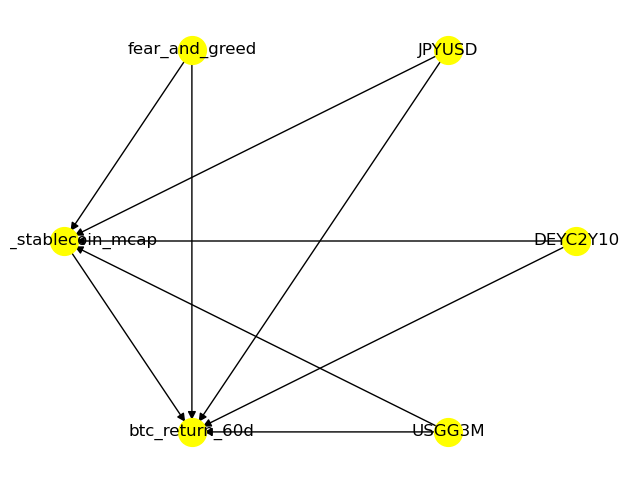

In [19]:
model = CausalModel(
    data=causal_df,
    treatment="total_stablecoin_mcap",
    outcome="btc_return_60d",
    common_causes=[
        "USGG3M",
        "DEYC2Y10",
        "JPYUSD",
        "fear_and_greed"
    ]
)

model.view_model()

In [31]:
pip install "networkx<3" --upgrade

  Using cached networkx-2.8.8-py3-none-any.whl.metadata (5.1 kB)
Using cached networkx-2.8.8-py3-none-any.whl (2.0 MB)
  Attempting uninstall: networkx
    Found existing installation: networkx 3.6.1
    Uninstalling networkx-3.6.1:
      Successfully uninstalled networkx-3.6.1
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dowhy 0.14 requires networkx>=3.3; python_version >= "3.10", but you have networkx 2.8.8 which is incompatible.
mapclassify 2.10.0 requires networkx>=3.2, but you have networkx 2.8.8 which is incompatible.
scikit-image 0.25.0 requires networkx>=3.0, but you have networkx 2.8.8 which is incompatible.


In [32]:
import dowhy, networkx
print(dowhy.__version__)
print(networkx.__version__)

0.8
3.6.1


In [33]:
identified_estimand = model.identify_effect()
print(identified_estimand)

AttributeError: module 'networkx.algorithms' has no attribute 'd_separated'

In [21]:
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression"
)

print("Causal effect estimate:", estimate.value)

NameError: name 'identified_estimand' is not defined

In [22]:
refutation = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="placebo_treatment_refuter"
)

print(refutation)

NameError: name 'identified_estimand' is not defined

## test causality 2

In [41]:
pip install graphviz 

Note: you may need to restart the kernel to use updated packages.


In [44]:
# ===============================
# CAUSAL PIPELINE (DoWhy) - VERSION CORRIGÉE v2
# ===============================

import pandas as pd
import numpy as np

# 1) Base DF
df = pivot_df.copy()

# Ensure datetime index
df.index = pd.to_datetime(df.index)

# 2) Create BTC log-return + horizon target (choose one)
HORIZON = 7  # change to 1, 7, 30, etc.

if "XBTUSD Curncy" not in df.columns:
    raise ValueError("BTC price column 'XBTUSD Curncy' missing.")

df["BTC_logret"] = np.log(df["XBTUSD Curncy"]).diff()

# Target = cumulative log-return over next HORIZON days
df["target"] = df["BTC_logret"].rolling(HORIZON).sum().shift(-HORIZON)

# Drop only where target or BTC is missing
df = df.dropna(subset=["BTC_logret", "target"])

# 3) OPTIONAL: filter date (if you want after 2018)
# df = df[df.index >= "2018-03-01"]

# 4) Fill missing values in features (important for macro series)
df = df.ffill().bfill()

# Remove columns you don't want as features
drop_cols = ["BTC_logret", "XBTUSD Curncy"]  # keep target

# -------------------------------
# Choose treatment candidates
# -------------------------------
treatments = [
    "VIX Index",
    "MOVE Index",
    "DXY Curncy",
    "USYC2Y10 Index",
    "DEYC2Y10 Index"
]

# keep only treatments present
treatments = [t for t in treatments if t in df.columns]
print("Treatments available:", treatments)

# -------------------------------
# Choose confounders (controls)
# -------------------------------
confounders = []
candidate_confounders = [
    "SPX Index", "CCMP Index", "RTY Index",
    "CL1 COMB Comdty", "NG1 COMB Comdty",
    "EURUSD Curncy", "JPYUSD Curncy", "CNH Curncy",
    "M2 Index", "ECMAM2 Index",
    "WGDPUS Index", "WGDPEURO Index"
]

confounders = [c for c in candidate_confounders if c in df.columns]
print("Confounders used:", confounders)

# -------------------------------
# Make causal dataset
# -------------------------------
causal_df = df[["target"] + treatments + confounders].copy()

# Ensure numeric
for col in causal_df.columns:
    causal_df[col] = pd.to_numeric(causal_df[col], errors="coerce")

causal_df = causal_df.dropna()
print("Causal df shape:", causal_df.shape)

# ===============================
# DoWhy Causal Estimation - SOLUTION GML FORMAT
# ===============================
from dowhy import CausalModel

results = []

for T in treatments:
    print("\n==============================")
    print("Treatment:", T, "| Outcome: target | Horizon:", HORIZON)

    # --------------------------
    # Créer le graphe en format GML (celui qui marche!)
    # --------------------------
    gml_graph = "graph [\n  directed 1\n"
    
    # Ajouter les nœuds
    gml_graph += f'  node [ id "{T}" label "{T}" ]\n'
    gml_graph += f'  node [ id "target" label "target" ]\n'
    
    for c in confounders:
        gml_graph += f'  node [ id "{c}" label "{c}" ]\n'
    
    # Ajouter les arêtes
    for c in confounders:
        gml_graph += f'  edge [ source "{c}" target "{T}" ]\n'
        gml_graph += f'  edge [ source "{c}" target "target" ]\n'
    
    gml_graph += f'  edge [ source "{T}" target "target" ]\n'
    gml_graph += "]\n"

    # Créer le modèle avec le graphe GML
    model = CausalModel(
        data=causal_df,
        treatment=T,
        outcome="target",
        graph=gml_graph
    )

    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    print("Identified estimand:", identified_estimand)

    # --------------------------
    # Estimate effect (backdoor)
    # --------------------------
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression"
    )

    print("Causal estimate (ATE):", estimate.value)

    # --------------------------
    # Refutation tests
    # --------------------------
    try:
        ref_placebo = model.refute_estimate(
            identified_estimand, estimate,
            method_name="placebo_treatment_refuter",
            placebo_type="permute"
        )
        placebo_new_est = getattr(ref_placebo, "new_effect", None)
        placebo_p = None
        if hasattr(ref_placebo, 'refutation_result'):
            placebo_p = ref_placebo.refutation_result.get('p_value', None)
        print("\nRefutation — placebo:", ref_placebo)
    except Exception as e:
        print(f"Placebo test failed: {e}")
        placebo_new_est = None
        placebo_p = None

    try:
        ref_randomcc = model.refute_estimate(
            identified_estimand, estimate,
            method_name="random_common_cause"
        )
        randomcc_new_est = getattr(ref_randomcc, "new_effect", None)
        print("Refutation — random common cause:", ref_randomcc)
    except Exception as e:
        print(f"Random common cause test failed: {e}")
        randomcc_new_est = None

    try:
        ref_subset = model.refute_estimate(
            identified_estimand, estimate,
            method_name="data_subset_refuter",
            subset_fraction=0.8
        )
        subset_new_est = getattr(ref_subset, "new_effect", None)
        print("Refutation — data subset:", ref_subset)
    except Exception as e:
        print(f"Subset test failed: {e}")
        subset_new_est = None

    results.append({
        "Horizon": HORIZON,
        "Treatment": T,
        "ATE": estimate.value,
        "Placebo_new_est": placebo_new_est,
        "Placebo_p": placebo_p,
        "RandomCC_new_est": randomcc_new_est,
        "Subset_new_est": subset_new_est
    })

# ===============================
# Results table
# ===============================
results_df = pd.DataFrame(results).sort_values("ATE", ascending=False, key=abs)
print("\n=== SUMMARY RESULTS ===")
display(results_df)

# Optional: save
# results_df.to_csv(f"causal_results_h{HORIZON}.csv", index=False)
# print(f"Saved: causal_results_h{HORIZON}.csv")

Treatments available: ['VIX Index', 'MOVE Index', 'DXY Curncy', 'USYC2Y10 Index', 'DEYC2Y10 Index']
Confounders used: ['SPX Index', 'CCMP Index', 'RTY Index', 'CL1 COMB Comdty', 'NG1 COMB Comdty', 'EURUSD Curncy', 'JPYUSD Curncy', 'CNH Curncy', 'M2 Index', 'ECMAM2 Index', 'WGDPUS Index', 'WGDPEURO Index']
Causal df shape: (5860, 18)

Treatment: VIX Index | Outcome: target | Horizon: 7
Identified estimand: Estimand type: nonparametric-ate

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                                         ↪
────────────(E[target|WGDPEURO Index,CNH Curncy,SPX Index,WGDPUS Index,M2 Inde ↪
d[VIX Index]                                                                   ↪

↪                                                                              ↪
↪ x,ECMAM2 Index,CL1 COMB Comdty,JPYUSD Curncy,CCMP Index,NG1 COMB Comdty,RTY  ↪
↪                                                                              ↪

↪      

C:\Users\marce\anaconda3\Lib\site-packages\dowhy\causal_estimators\regression_estimator.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
C:\Users\marce\anaconda3\Lib\site-packages\dowhy\causal_estimators\regression_estimator.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
C:\Users\marce\anaconda3\Lib\site-packages\dowhy\causal_estimators\regression_estimator.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with D

{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate

C:\Users\marce\anaconda3\Lib\site-packages\dowhy\causal_estimators\regression_estimator.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
C:\Users\marce\anaconda3\Lib\site-packages\dowhy\causal_estimators\regression_estimator.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
C:\Users\marce\anaconda3\Lib\site-packages\dowhy\causal_estimators\regression_estimator.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with D

{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate

...

C:\Users\marce\anaconda3\Lib\site-packages\dowhy\causal_estimators\regression_estimator.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
C:\Users\marce\anaconda3\Lib\site-packages\dowhy\causal_estimators\regression_estimator.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
C:\Users\marce\anaconda3\Lib\site-packages\dowhy\causal_estimators\regression_estimator.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with D

{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate

C:\Users\marce\anaconda3\Lib\site-packages\dowhy\causal_estimators\regression_estimator.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
C:\Users\marce\anaconda3\Lib\site-packages\dowhy\causal_estimators\regression_estimator.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
C:\Users\marce\anaconda3\Lib\site-packages\dowhy\causal_estimators\regression_estimator.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with D

{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate

,Horizon,Treatment,ATE,Placebo_new_est,Placebo_p,RandomCC_new_est,Subset_new_est
2,7,DXY Curncy,0.010978,1.440039e-05,0.96,0.010980,0.010822
3,7,USYC2Y10 Index,0.000173,7.588360e-07,0.90,0.000173,0.000167
4,7,DEYC2Y10 Index,0.000164,4.128377e-06,0.80,0.000164,0.000167
0,7,VIX Index,0.000087,1.917510e-05,0.92,0.000087,0.000084
1,7,MOVE Index,0.000042,1.238027e-05,0.86,0.000042,0.000041


In [45]:
# ===============================
# CAUSAL PIPELINE
# ===============================

import pandas as pd
import numpy as np
from dowhy import CausalModel

# 1) Base DF
df = pivot_df.copy()
df.index = pd.to_datetime(df.index)

# =================================
HORIZON = 30  # 1, 7, 30, 90, etc.
# =================================

if "XBTUSD Curncy" not in df.columns:
    raise ValueError("BTC price column 'XBTUSD Curncy' missing.")

df["BTC_logret"] = np.log(df["XBTUSD Curncy"]).diff()
df["target"] = df["BTC_logret"].rolling(HORIZON).sum().shift(-HORIZON)
df = df.dropna(subset=["BTC_logret", "target"])
df = df.ffill().bfill()

# Treatments
treatments = [
    "VIX Index",
    "MOVE Index", 
    "DXY Curncy",
    "USYC2Y10 Index",
    "DEYC2Y10 Index"
]
treatments = [t for t in treatments if t in df.columns]

# Confounders
candidate_confounders = [
    "SPX Index", "CCMP Index", "RTY Index",
    "CL1 COMB Comdty", "NG1 COMB Comdty",
    "EURUSD Curncy", "JPYUSD Curncy", "CNH Curncy",
    "M2 Index", "ECMAM2 Index",
    "WGDPUS Index", "WGDPEURO Index"
]
confounders = [c for c in candidate_confounders if c in df.columns]

# Causal dataset
causal_df = df[["target"] + treatments + confounders].copy()
for col in causal_df.columns:
    causal_df[col] = pd.to_numeric(causal_df[col], errors="coerce")
causal_df = causal_df.dropna()

print(f"\n{'='*50}")
print(f"HORIZON: {HORIZON} days | Sample size: {len(causal_df)}")
print(f"{'='*50}\n")

# ===============================
# LOOP - AFFICHAGE MINIMAL
# ===============================

results = []

for T in treatments:
    # Build GML graph
    gml_graph = "graph [\n  directed 1\n"
    gml_graph += f'  node [ id "{T}" label "{T}" ]\n'
    gml_graph += f'  node [ id "target" label "target" ]\n'
    
    for c in confounders:
        gml_graph += f'  node [ id "{c}" label "{c}" ]\n'
    
    for c in confounders:
        gml_graph += f'  edge [ source "{c}" target "{T}" ]\n'
        gml_graph += f'  edge [ source "{c}" target "target" ]\n'
    
    gml_graph += f'  edge [ source "{T}" target "target" ]\n'
    gml_graph += "]\n"

    # Causal model
    model = CausalModel(
        data=causal_df,
        treatment=T,
        outcome="target",
        graph=gml_graph
    )

    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression"
    )

    # Refutation tests (silent)
    try:
        ref_placebo = model.refute_estimate(
            identified_estimand, estimate,
            method_name="placebo_treatment_refuter",
            placebo_type="permute"
        )
        placebo_new_est = getattr(ref_placebo, "new_effect", None)
        placebo_p = ref_placebo.refutation_result.get('p_value', None) if hasattr(ref_placebo, 'refutation_result') else None
    except:
        placebo_new_est = None
        placebo_p = None

    try:
        ref_randomcc = model.refute_estimate(
            identified_estimand, estimate,
            method_name="random_common_cause"
        )
        randomcc_new_est = getattr(ref_randomcc, "new_effect", None)
    except:
        randomcc_new_est = None

    try:
        ref_subset = model.refute_estimate(
            identified_estimand, estimate,
            method_name="data_subset_refuter",
            subset_fraction=0.8
        )
        subset_new_est = getattr(ref_subset, "new_effect", None)
    except:
        subset_new_est = None

    results.append({
        "Horizon": HORIZON,
        "Treatment": T,
        "ATE": estimate.value,
        "Placebo_new_est": placebo_new_est,
        "Placebo_p": placebo_p,
        "RandomCC_new_est": randomcc_new_est,
        "Subset_new_est": subset_new_est
    })
    
    # Affichage minimal par traitement
    print(f"{T:20s} | ATE: {estimate.value:10.6f}")

# ===============================
# RESULTS
# ===============================
results_df = pd.DataFrame(results).sort_values("ATE", ascending=False, key=abs)

print(f"\n{'='*50}")
print("=== SUMMARY RESULTS ===")
print(f"{'='*50}")
display(results_df)

# Save
results_df.to_csv(f"causal_results_h{HORIZON}.csv", index=False)
print(f"\n✓ Saved: causal_results_h{HORIZON}.csv")


HORIZON: 30 days | Sample size: 5837

linear_regression
{'control_value': 0, 'treatment_value': 1, 'test_significance': None, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}


C:\Users\marce\anaconda3\Lib\site-packages\dowhy\causal_estimators\regression_estimator.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
C:\Users\marce\anaconda3\Lib\site-packages\dowhy\causal_estimators\regression_estimator.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
C:\Users\marce\anaconda3\Lib\site-packages\dowhy\causal_estimators\regression_estimator.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with D

{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate

C:\Users\marce\anaconda3\Lib\site-packages\dowhy\causal_estimators\regression_estimator.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
C:\Users\marce\anaconda3\Lib\site-packages\dowhy\causal_estimators\regression_estimator.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
C:\Users\marce\anaconda3\Lib\site-packages\dowhy\causal_estimators\regression_estimator.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with D

{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate

...

C:\Users\marce\anaconda3\Lib\site-packages\dowhy\causal_estimators\regression_estimator.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
C:\Users\marce\anaconda3\Lib\site-packages\dowhy\causal_estimators\regression_estimator.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
C:\Users\marce\anaconda3\Lib\site-packages\dowhy\causal_estimators\regression_estimator.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with D

{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': []}
{'control_value': 0, 'treatment_value': 1, 'test_significance': False, 'evaluate

C:\Users\marce\anaconda3\Lib\site-packages\dowhy\causal_estimators\regression_estimator.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
C:\Users\marce\anaconda3\Lib\site-packages\dowhy\causal_estimators\regression_estimator.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]


,Horizon,Treatment,ATE,Placebo_new_est,Placebo_p,RandomCC_new_est,Subset_new_est
2,30,DXY Curncy,0.047024,-0.000070,0.96,0.047025,0.047254
0,30,VIX Index,0.001523,-0.000073,0.86,0.001524,0.001403
1,30,MOVE Index,0.001262,-0.000017,1.00,0.001262,0.001255
3,30,USYC2Y10 Index,0.000924,-0.000006,0.88,0.000924,0.000904
4,30,DEYC2Y10 Index,0.000759,-0.000003,0.98,0.000760,0.000777



✓ Saved: causal_results_h30.csv
